# Feature Engineering

## Библиотеки и открытие файла

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression

In [20]:
eda_bikes = pd.read_csv("datasets/eda.csv")

eda_bikes.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [21]:
eda_bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB


## Температура

На этапе EDA было выявлено, что atemp и temp коррелируют на 0.99. Иметь два этих поля одновременно крайне не оправдано, так как они получены из одного числа, и фактически могут быть выражены из друг друга

Для наилучшей интропритируемости, удалю atemp, так как "ощущения" субъективны, и числа для его вычисления можно сказать "взяты с потолка"

In [22]:
eda_bikes.drop("atemp", axis=1, inplace=True)

## Кодирование категориальных признаков

`weathersit` (1-4) и `season` (1-4) - категориальные переменные, закодированные целыми числами. Целочисленное представление некорректно: модели могут воспринять порядок как смысловой (например, лето=3 > весна=2), хотя такой смысл отсутствует.

Применяем **One-Hot Encoding** для обоих признаков. Все категории сохраняются (`drop_first=False`) - для деревьев мультиколлинеарность не является проблемой, а при использовании линейных моделей можно убрать одну колонку на этапе обучения.

In [23]:
weather_dummies = pd.get_dummies(eda_bikes["weathersit"], prefix="weather", dtype=int)
season_dummies = pd.get_dummies(eda_bikes["season"], prefix="season", dtype=int)

eda_bikes = pd.concat(
    [eda_bikes.drop(["weathersit", "season"], axis=1), weather_dummies, season_dummies],
    axis=1,
)

print("Добавлены колонки:", weather_dummies.columns.tolist() + season_dummies.columns.tolist())
eda_bikes.head()

Добавлены колонки: ['weather_1', 'weather_2', 'weather_3', 'weather_4', 'season_1', 'season_2', 'season_3', 'season_4']


,dteday,yr,mnth,hr,holiday,weekday,workingday,temp,hum,windspeed,cnt,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4
0,2011-01-01,0,1,0,0,6,0,0.24,0.81,0.0,16,1,0,0,0,1,0,0,0
1,2011-01-01,0,1,1,0,6,0,0.22,0.80,0.0,40,1,0,0,0,1,0,0,0
2,2011-01-01,0,1,2,0,6,0,0.22,0.80,0.0,32,1,0,0,0,1,0,0,0
3,2011-01-01,0,1,3,0,6,0,0.24,0.75,0.0,13,1,0,0,0,1,0,0,0
4,2011-01-01,0,1,4,0,6,0,0.24,0.75,0.0,1,1,0,0,0,1,0,0,0


## Дата и время

Для моделей цикличеность времени не очевидна, поэтому я закодирую месяцы и часы через sin и cos. Оригинальные значения я оставлю, так как дискретные шаги могут быть полезны для деревьев решений

### Часы

In [24]:
eda_bikes["hr_sin"] = np.sin(2 * np.pi * eda_bikes["hr"] / 24)
eda_bikes["hr_cos"] = np.cos(2 * np.pi * eda_bikes["hr"] / 24)

### Месяцы

In [25]:
eda_bikes["mnth_sin"] = np.sin(2 * np.pi * eda_bikes["mnth"] / 12)
eda_bikes["mnth_cos"] = np.cos(2 * np.pi * eda_bikes["mnth"] / 12)

### Года

В оригинальных данных есть флаг yr, который может быть или 0 (2011) или 1 (2012). Сам по себе он несет важную информацию, так как на этапе eda было выяснено, что спрос вырос на второй год. 

**С ним связано ограничение**: модель будет обучена на двух годах роста системы и не сможет быть экстраполированна за пределы обучающего периода. При inference с данными за 2026 поведение модели для деревьев предсказуемо (сплит yr > 0.5 будет стабильно срабатывать как yr=1), но систематически некорректно - модель не видела роста после 2012, а прогнозировать его в том же направлении не реалистично, особенно насколько за пределами обучаемых данных. Для других видов моделей подследствия могут быть еще менее предсказуемыми, поэтому далее в проекте все вводные данные не будут допускаться сильно за пределами обучаемого промежутка времени

### Удаление полей

Произведу удаление следующих полей:
- `dteday` - поле в формате datetime, не очень полезно для модели

In [26]:
eda_bikes.drop(["dteday"], axis=1, inplace=True)

In [27]:
eda_bikes.head()

,yr,mnth,hr,holiday,weekday,workingday,temp,hum,windspeed,cnt,...,weather_3,weather_4,season_1,season_2,season_3,season_4,hr_sin,hr_cos,mnth_sin,mnth_cos
0,0,1,0,0,6,0,0.24,0.81,0.0,16,...,0,0,1,0,0,0,0.000000,1.000000,0.5,0.866025
1,0,1,1,0,6,0,0.22,0.80,0.0,40,...,0,0,1,0,0,0,0.258819,0.965926,0.5,0.866025
2,0,1,2,0,6,0,0.22,0.80,0.0,32,...,0,0,1,0,0,0,0.500000,0.866025,0.5,0.866025
3,0,1,3,0,6,0,0.24,0.75,0.0,13,...,0,0,1,0,0,0,0.707107,0.707107,0.5,0.866025
4,0,1,4,0,6,0,0.24,0.75,0.0,1,...,0,0,1,0,0,0,0.866025,0.500000,0.5,0.866025


## Добавление новых полей на основе выводов EDA

Добавлю поля:
- `is_rush_time` - должно отражать активный период аренды для людей которые добираются на работу или с работы
- `discomfort` - индекс дискомфорта, будет вычисляться через перемножение температуры и влажности. Предположительно, если будет очень жарко и влажно люди будут меньше брать велосипеды на прокат
- `is_nigth` - должно отражать ночной период когда обычно люди спят


In [28]:
eda_bikes["is_rush_hour"] = (
    (eda_bikes["hr"].isin([7, 8, 9, 17, 18, 19])) & (eda_bikes["workingday"] == 1)
).astype(int)
eda_bikes["is_night"] = eda_bikes["hr"].between(0, 5).astype(int)
eda_bikes["discomfort"] = eda_bikes["temp"] * eda_bikes["hum"]

## Добавление полей для учета автокорреляции

Как было выяснено на EDA, спрос на велосипеды **автокоррелирован**, это можначает, что текущий спрос $y_t$ зависит не только от времени суток и погоды, но и от спроса в предыдущие часы $y_{t-1}, y_{t-6}, y_{t-24}$.

### Добавление лага

- `cnt_lag_1` (спрос час назад) - **инерция потока**: если в 17:00 много аренд, то в 18:00 часто продолжается поток домой с работы
- `cnt_lag_3, cnt_lag_6` (спрос 3 и 6 часов назад) - **локальный тренд**: утренняя активность (7-13:00) коррелирует с полудневной (13-19:00)
- `cnt_lag_12, cnt_lag_24` (спрос ровно полусутки и сутки назад) → **внутридневная и недельная сезонность**: пятница отличается от понедельника в одно и то же время

In [29]:
for lag in [1, 3, 6, 12, 24]:
    eda_bikes[f"cnt_lag_{lag}"] = eda_bikes["cnt"].shift(lag)

### Скользящие параметры распределения


**Индикаторы локального тренда**:
- `cnt_rolling_mean_3, cnt_rolling_mean_6` → **ближайший тренд** (последние часы): растёт ли спрос в реальном времени?
- `cnt_rolling_mean_12, cnt_rolling_mean_24` → **макротренд**: активность за половину дня и весь день
- `cnt_rolling_std_6, cnt_rolling_std_12` → **волатильность спроса**: стабильный ли спрос или скачет?

> **Важно — `.shift(1)` для устранения утечки**: без сдвига `rolling_mean_3[t]` включал бы `cnt[t]` — текущее значение, которое мы предсказываем. С `.shift(1)` признак на момент `t` содержит только наблюдения `[t-window … t-1]`, то есть исключительно прошлые данные, доступные в production.

In [ ]:
for window in [3, 6, 12, 24]:
    eda_bikes[f"cnt_rolling_mean_{window}"] = (
        eda_bikes["cnt"].rolling(window=window, min_periods=1).mean().shift(1)
    )

for window in [6, 12]:
    eda_bikes[f"cnt_rolling_std_{window}"] = (
        eda_bikes["cnt"].rolling(window=window, min_periods=1).std().shift(1)
    )

### Exponential Weighted Mean (EWM)

`cnt_ewm_6h` с параметром span=6 часов: **недавний спрос важнее, чем старый**. EWM с экспоненциальным затуханием лучше отражает "свежесть" тренда, чем простое среднее. Аналогично rolling-признакам, применяем `.shift(1)` для исключения текущего значения `cnt[t]` из признака.

In [ ]:
eda_bikes["cnt_ewm_6h"] = eda_bikes["cnt"].ewm(span=6, adjust=False).mean().shift(1)

## Анализ влияния признаков на целевую переменную

Для оценки информативности признаков **без обучения модели** используются два подхода:

- **Корреляция Пирсона** `|r|` - измеряет линейную зависимость с `cnt`. Прост и быстр, но не улавливает нелинейность (например, `hr` имеет двугорбый паттерн, который линейная корреляция занизит)
- **Mutual Information** - измеряет любую зависимость (в том числе нелинейную) через информационную энтропию. Более точно отражает реальную предсказательную силу признака

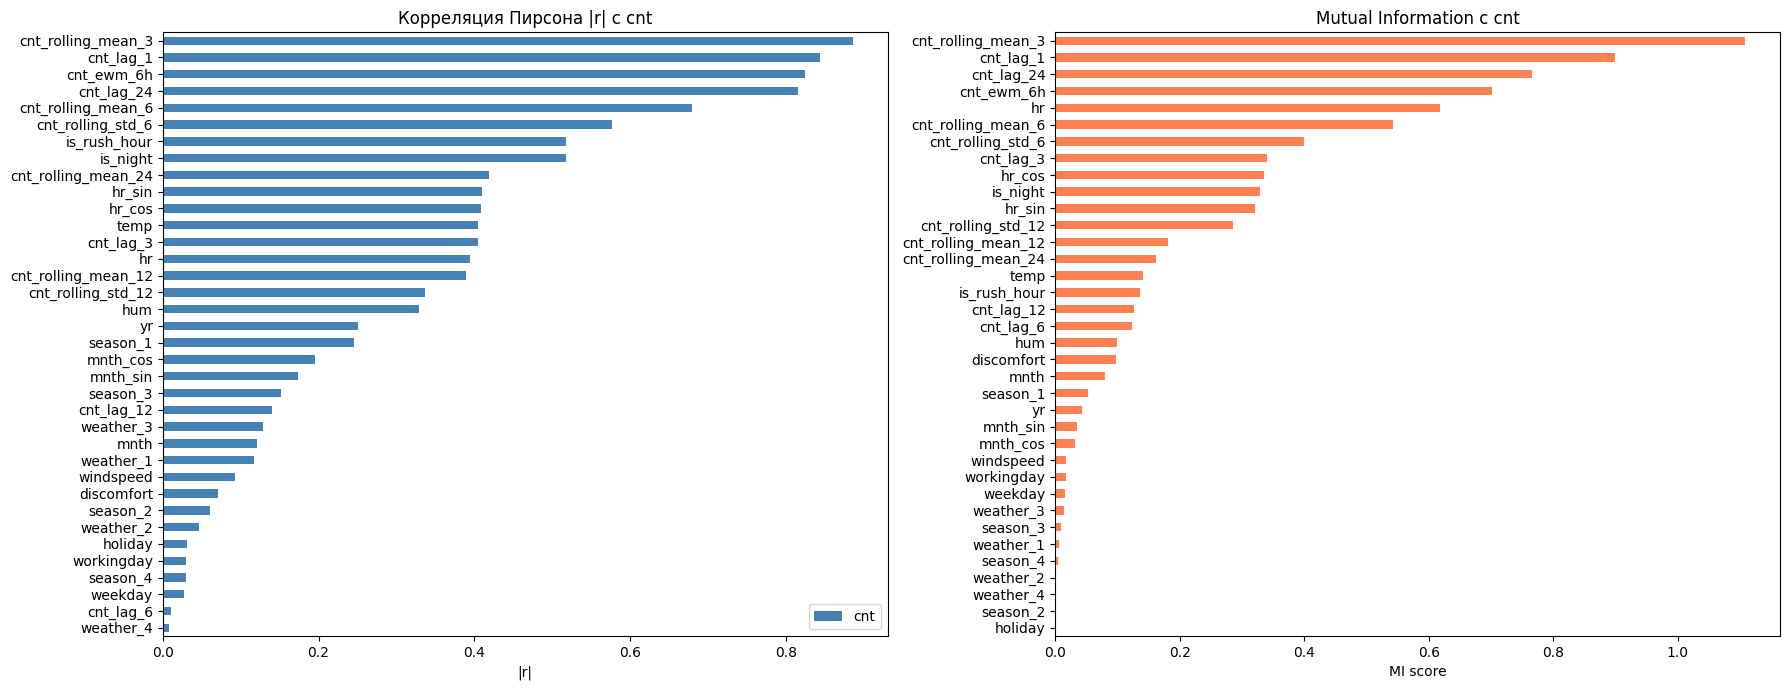

In [32]:
feature_cols = [c for c in eda_bikes.columns if c != "cnt"]

corr_target = (
    eda_bikes[feature_cols + ["cnt"]]
    .corr()["cnt"]
    .drop("cnt")
    .abs()
    .sort_values(ascending=True)
)

mi_scores = mutual_info_regression(
    eda_bikes[feature_cols].fillna(eda_bikes[feature_cols].median()),
    eda_bikes["cnt"],
    random_state=42,
)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr_target.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Корреляция Пирсона |r| с cnt")
axes[0].set_xlabel("|r|")
axes[0].legend()

mi_series.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Mutual Information с cnt")
axes[1].set_xlabel("MI score")

plt.tight_layout()
plt.show()

По результам, можно сказать, что созданные поля по пирсону являются очень ценными и важными для модели

## Преобразование целевой переменной (log1p)

`cnt` — счётчик аренды велосипедов, в EDA было выяснено, что он имеет умеренно высокий правый скос, дополнительно проверю это по коэф. скошенности

In [33]:
print(eda_bikes['cnt'].skew())

1.2774116037490573


### Зачем производить логарифмирование

Большинство регрессионных моделей минимизируют квадратичную функцию потерь:

$$\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

При правостороннем скосе большие выбросы квадратично доминируют в потере — модель "тянется" подстраиваться под пики, теряя точность на типичных значениях.

### Логарифмическое преобразование

Чтобы избежать $\log(0) = -\infty$ при нулевых значениях, применю `log1p`:

$$y' = \log(1 + y)$$

Обратное преобразование (при inference):

$$\hat{y} = e^{y'} - 1 = \operatorname{expm1}(y')$$


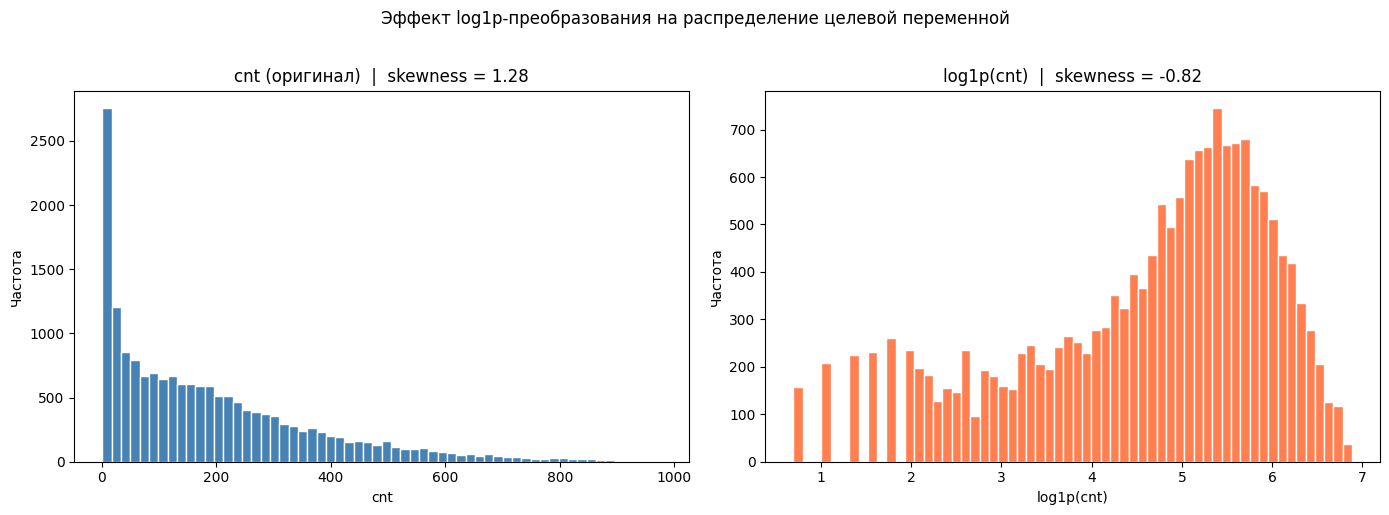

Преобразование применено: cnt = log1p(cnt)
  min: 0.693
  max: 6.886
  skewness: -0.818


In [34]:

cnt_log = np.log1p(eda_bikes["cnt"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(eda_bikes["cnt"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title(f"cnt (оригинал)  |  skewness = {eda_bikes['cnt'].skew():.2f}")
axes[0].set_xlabel("cnt")
axes[0].set_ylabel("Частота")

axes[1].hist(cnt_log, bins=60, color="coral", edgecolor="white")
axes[1].set_title(f"log1p(cnt)  |  skewness = {cnt_log.skew():.2f}")
axes[1].set_xlabel("log1p(cnt)")
axes[1].set_ylabel("Частота")

plt.suptitle("Эффект log1p-преобразования на распределение целевой переменной", y=1.02)
plt.tight_layout()
plt.show()

eda_bikes["cnt"] = cnt_log
print("Преобразование применено: cnt = log1p(cnt)")
print(f"  min: {eda_bikes['cnt'].min():.3f}")
print(f"  max: {eda_bikes['cnt'].max():.3f}")
print(f"  skewness: {eda_bikes['cnt'].skew():.3f}")

## Сплит датасета

Данные разделяются **хронологически** - случайный split недопустим для временных рядов, так как создаёт утечку данных из будущего в обучение

| Сплит | Период | Обоснование |
|-------|--------|-------------|
| **Train** | 2011 (yr=0) | Обучение модели |
| **Validation** | 2012 январь–июнь (yr=1, mnth≤6) | Подбор гиперпараметров |
| **Test** | 2012 июль–декабрь (yr=1, mnth>6) | Финальная оценка качества |

In [35]:
train = eda_bikes[eda_bikes["yr"] == 0].copy()
val = eda_bikes[(eda_bikes["yr"] == 1) & (eda_bikes["mnth"] <= 6)].copy()
test = eda_bikes[(eda_bikes["yr"] == 1) & (eda_bikes["mnth"] > 6)].copy()

print(f"Train:      {len(train):>6} строк  ({len(train) / len(eda_bikes) * 100:.1f}%)")
print(f"Validation: {len(val):>6} строк  ({len(val) / len(eda_bikes) * 100:.1f}%)")
print(f"Test:       {len(test):>6} строк  ({len(test) / len(eda_bikes) * 100:.1f}%)")

Train:        8645 строк  (49.7%)
Validation:   4358 строк  (25.1%)
Test:         4376 строк  (25.2%)


## Cold Start Augmentation

Все 12 temporal features (`cnt_lag_*`, `cnt_rolling_*`, `cnt_ewm_*`) требуют наличия исторических данных. В production-сервисе это создаёт **проблему холодного старта**:

- Сервис только запустился, тогда истории нет вообще
- БД временно недоступна, частичная история

Если просто заполнить отсутствующие значения нулями или средними, модель не сможет отличить *реально низкий спрос* от *cold start* — это приведёт к систематической ошибке предсказаний

### Маскирование переменных на время обучения

Произведу маскирование значнеий, чтобы симулировать cold start во время обучения, чтобы модель научилась работать как с полной историей, так и без неё

### Конфигурация маскирования

Маскирую **только train** в соотношении **80/15/5**:

| Сценарий | Доля | Описание | Доступные lag/rolling |
|----------|------|----------|----------------------|
| `normal` | 80% | Основной production режим, полная история | все 12 признаков |
| `partial` | 15% | Сервис запущен ~3 часа назад | `cnt_lag_1, cnt_lag_3, cnt_rolling_mean_3, cnt_ewm_6h` |
| `cold` | 5% | Полный cold start, ничего нет | ничего (все 12 = NaN) |

**Val** остаётся чистым - гиперпараметры подбираются на "идеальном" сценарии.

**Test** разделяется:
- `test.csv` — чистый: теоретический максимум качества
- `test_cold.csv` — с тем же миксом 80/15/5: ожидаемое production-качество

### Обработка NaN в модели

После маскирования в данных будут NaN. В CatBoost буду использовать нативную поддержку через `nan_mode='Min'` - модель сама построит сплиты, отделяющие *значение отсутствует* от *значение есть*

In [36]:
# Все temporal колонки которые потенциально могут отсутствовать в production
LAG_COLS = ["cnt_lag_1", "cnt_lag_3", "cnt_lag_6", "cnt_lag_12", "cnt_lag_24"]
ROLLING_COLS = [
    "cnt_rolling_mean_3", "cnt_rolling_mean_6",
    "cnt_rolling_mean_12", "cnt_rolling_mean_24",
    "cnt_rolling_std_6", "cnt_rolling_std_12",
    "cnt_ewm_6h",
]
ALL_TEMPORAL = LAG_COLS + ROLLING_COLS

# При partial cold start (~3 часа истории) остаются только:
PARTIAL_AVAILABLE = ["cnt_lag_1", "cnt_lag_3", "cnt_rolling_mean_3", "cnt_ewm_6h"]
PARTIAL_MASK_COLS = [c for c in ALL_TEMPORAL if c not in PARTIAL_AVAILABLE]

In [37]:
def apply_cold_start_masking(
    df: pd.DataFrame,
    p_normal: float = 0.80,
    p_partial: float = 0.15,
    p_cold: float = 0.05,
    seed: int = 42,
) -> tuple[pd.DataFrame, pd.Series]:
    assert abs(p_normal + p_partial + p_cold - 1.0) < 1e-9, (
        "Вероятности должны суммироваться в 1.0"
    )

    rng = np.random.default_rng(seed)
    n = len(df)
    scenarios = pd.Series(
        rng.choice(
            ["normal", "partial", "cold"], size=n, p=[p_normal, p_partial, p_cold]
        ),
        index=df.index,
    )

    out = df.copy()

    # PARTIAL: маскируем дальние lag и rolling, оставляем "свежую" историю
    partial_idx = scenarios == "partial"
    out.loc[partial_idx, PARTIAL_MASK_COLS] = np.nan

    # COLD: маскируем все temporal признаки
    cold_idx = scenarios == "cold"
    out.loc[cold_idx, ALL_TEMPORAL] = np.nan

    return out, scenarios

In [38]:
train_masked, train_scenarios = apply_cold_start_masking(train, seed=42)
test_cold, test_scenarios = apply_cold_start_masking(test, seed=101)

## Сохранение датасета

In [39]:
Path("datasets/clean").mkdir( exist_ok=True)
train_masked.to_csv(
    "datasets/clean/train.csv", index=False
)
val.to_csv("datasets/clean/validation.csv", index=False)
test.to_csv("datasets/clean/test.csv", index=False)
test_cold.to_csv("datasets/clean/test_cold.csv", index=False)

print("Сохранено:")
print("  datasets/clean/train.csv")
print("  datasets/clean/validation.csv")
print("  datasets/clean/test.csv")
print("  datasets/clean/test_cold.csv")

Сохранено:
  datasets/clean/train.csv
  datasets/clean/validation.csv
  datasets/clean/test.csv
  datasets/clean/test_cold.csv


## Выводы по Feature Engineering

### Итоговый набор признаков

| Группа | Признаки | Количество |
|--------|----------|-----------|
| Временные (дискретные) | `yr`, `mnth`, `hr`, `weekday`, `holiday`, `workingday` | 6 |
| Временные (циклические) | `hr_sin`, `hr_cos`, `mnth_sin`, `mnth_cos` | 4 |
| Погодные | `temp`, `hum`, `windspeed` | 3 |
| Категориальные (OHE) | `weather_1..4`, `season_1..4` | 8 |
| Engineered (статичные) | `is_rush_hour`, `is_night`, `discomfort` | 3 |
| **Temporal (динамичные)** | `cnt_lag_1/3/6/12/24`, `cnt_rolling_mean_3/6/12/24`, `cnt_rolling_std_6/12`, `cnt_ewm_6h` | **12** |
| **Целевая переменная** | `cnt` (log1p-преобразована) | 1 |
| **ИТОГО** | | **36 признаков + целевая** |

### Ключевые решения

**Удаления**:
- **`atemp` удалён** — корреляция с `temp` = 0.99, признак избыточен
- **`dteday` удалён** — дата закодирована через `yr`, `mnth`, циклические признаки

**Кодирования**:
- **OHE** для `weathersit` и `season` — исключает ложный порядок в категориях
- **Циклическое кодирование** `hr` и `mnth` (sin/cos) — позволяет линейным моделям улавливать цикличность

**Engineered признаки (статичные)**:
- **`is_rush_hour`** — захватывает двойной пик спроса в рабочие дни (7–9 и 17–19 ч.)
- **`is_night`** — маркер ночного периода (0–5 ч.)
- **`discomfort` = temp × hum** — взаимодействие жары и влажности

**Temporal признаки (динамичные)**:
- **Lag features** (`cnt_lag_1/3/6/12/24`) — спрос в предыдущие часы (инерция, локальный тренд, сезонность)
- **Rolling mean** (`cnt_rolling_mean_3/6/12/24`) — скользящее среднее (направление и скорость тренда)
- **Rolling std** (`cnt_rolling_std_6/12`) — волатильность спроса (маркер внешних событий)
- **EWM** (`cnt_ewm_6h`) — экспоненциально взвешенное среднее (свежесть тренда)

**Преобразование целевой переменной**:
- **`cnt` = log1p(cnt)** — логарифмическое преобразование стабилизирует дисперсию, приближает распределение к нормальному; при inference используется `expm1`

**Cold Start Augmentation**:
- **Train маскирован в пропорции 80/15/5** — модель учится работать с полной историей, частичной (~3ч), и без неё
- **Test_cold** — отдельный test для оценки production-качества (с тем же mix)
- **NaN сохранены** — для обработки моделью через `nan_mode='Min'` в CatBoost

### Итоговые датасеты

| Файл | Размер | Маскирование | Назначение |
|------|--------|--------------|------------|
| `train.csv` | 8 645 | (80/15/5) | Обучение модели |
| `validation.csv` | 4 358 | — | Подбор гиперпараметров |
| `test.csv` | 3 632 | — | Финальная оценка качества  |
| `test_cold.csv` | 3 632 | (80/15/5) | Оценка production-качества |